# **EMIF Group Project 1**
#### Aymen Laraoui, Rijad Talovic, Alexis Gavillet, Clémence Choukroun

## Data Cleaning : Weekly Frequency

Selected Variables
- **WTI** : WTI crude oil futures (CL1 Comdty)
- **HY** : Bloomberg US Corporate High Yield Index (LF98YW Index)
- **SP500** : S&P 500 Index (SPX Index)
- **US2Y** : US Government 2-Year Yield (USGG2YR Index)

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Data Loading

In [13]:
raw_path = Path("../data/raw/data_hec_projet_1.xlsx")
daily_raw = pd.read_excel(raw_path, sheet_name="Daily", skiprows=5, index_col=0, parse_dates=True)

print("Raw dimensions:", daily_raw.shape)
daily_raw.head()

Raw dimensions: (9443, 13)


,PX_LAST,PX_LAST.1,PX_LAST.2,PX_LAST.3,PX_LAST.4,PX_LAST.5,PX_LAST.6,PX_LAST.7,PX_LAST.8,PX_LAST.9,PX_LAST.10,PX_LAST.11,PX_LAST.12
Dates,,,,,,,,,,,,,
1990-01-01,21.82,19.69,77.8405,NaN,NaN,353.40,567.34,214.69,168.228,7.935,7.841,16.08,401.25
1990-01-02,22.89,19.90,81.0621,NaN,NaN,359.69,568.96,217.30,169.943,7.930,7.875,16.08,399.00
1990-01-03,23.68,20.95,83.0504,NaN,NaN,358.76,569.10,220.45,170.780,7.974,7.927,16.08,395.00
1990-01-04,23.41,20.78,81.1315,NaN,NaN,355.67,571.02,227.30,170.168,7.972,7.910,16.08,396.50
1990-01-05,23.08,20.75,78.7509,NaN,NaN,352.20,566.36,228.91,169.713,7.984,7.885,16.08,405.00


In [14]:
#filtering for selected variables
df = daily_raw.iloc[:, [0, 5, 10, 11]].copy()
df.columns = ["WTI", "SP500", "US2Y", "HY"]

df.head()

,WTI,SP500,US2Y,HY
Dates,,,,
1990-01-01,21.82,353.40,7.841,16.08
1990-01-02,22.89,359.69,7.875,16.08
1990-01-03,23.68,358.76,7.927,16.08
1990-01-04,23.41,355.67,7.910,16.08
1990-01-05,23.08,352.20,7.885,16.08


Here, we noticed that HY variable hasn't always been daily but monthly. This means that for most weeks within a month, the resampled weekly value is just a repeat of the same monthly observation, which produces zeros in d_spread_hy between month-end dates. The code below identifies exactly when HY started being reported at higher frequency.

In [15]:
# keep only the dates where HY actually changed
hy_changes = df["HY"].dropna()
hy_changes = hy_changes[hy_changes != hy_changes.shift(1)]

# gap in days between each change
gaps = hy_changes.index.to_series().diff().dt.days.dropna()

# last date where the gap was still monthly
print(gaps[gaps >= 20].index[-1].date())

1998-07-31


We considered three ways to handle this. First, restricting the sample to the period when HY becomes available at daily frequency. Second, downsampling all variables to monthly frequency to keep the full 1990-2026 period. Third, keeping the full sample and simply acknowledging the limitation.

We go with the first option. The artificial zeros in `d_spread_hy` and the downward bias in `var_hy` are not just a cosmetic issue — they directly affect VAR estimation. Monthly resampling would mean losing the weekly granularity the model relies on. And keeping the full sample while noting the problem is not rigorous enough given how much of the early period is affected. Cutting the sample is the cleanest solution.

In [16]:
# cut the sample from the date HY starts being reported at daily frequency
df = df.loc["1998-08-01":]

## 2. Weekly resampling of daily data

In [17]:
# for each week, keep the last available observation (approximates weekly close)
df_weekly = df.resample("W-FRI").last()

print(f"Period: {df_weekly.index[0].date()} to {df_weekly.index[-1].date()}")
df_weekly.head()

Period: 1998-08-07 to 2026-03-13


,WTI,SP500,US2Y,HY
Dates,,,,
1998-08-07,14.14,1089.45,5.328,9.03
1998-08-14,13.64,1062.75,5.318,9.31
1998-08-21,13.37,1081.24,5.197,9.56
1998-08-28,13.50,1027.14,4.905,10.01
1998-09-04,14.59,973.89,4.902,10.56


## 3. Returns & Excess Returns

In [18]:
df_ret = df_weekly.copy()

# log-returns for WTI and SP500 (price series)
for col in ["WTI", "SP500"]:
    df_ret[col] = np.log(df_weekly[col] / df_weekly[col].shift(1))

# weekly risk-free rate (annualized % to weekly decimal)
df_ret["US2Y"] = df_weekly["US2Y"] / (100 * 52)

# VAR 1 variables
ret_wti  = df_ret["WTI"].rename("ret_wti")
er_sp500 = (df_ret["SP500"] - df_ret["US2Y"]).rename("er_sp500")

# HY (LF98YW) is a yield to worst in %, not a price index
# so we take the change in spread (HY - US2Y), converted to decimal
spread_hy   = df_weekly["HY"] - df_weekly["US2Y"]
d_spread_hy = ((spread_hy - spread_hy.shift(1)) / 100).rename("d_spread_hy")

## 4. Realized Variance

In [19]:
# daily log-returns for WTI and SP500
daily_ret_wti   = np.log(df["WTI"] / df["WTI"].shift(1)).dropna()
daily_ret_sp500 = np.log(df["SP500"] / df["SP500"].shift(1)).dropna()

# daily first differences of the HY spread
daily_spread   = df["HY"] - df["US2Y"]
daily_d_spread = ((daily_spread - daily_spread.shift(1)) / 100).dropna()

# realized variance: sum of squared daily returns within each week
rv_wti   = (daily_ret_wti ** 2).resample("W-FRI").sum().rename("rv_wti")
rv_sp500 = (daily_ret_sp500 ** 2).resample("W-FRI").sum().rename("rv_sp500")
rv_hy    = (daily_d_spread ** 2).resample("W-FRI").sum().rename("rv_hy")

## 5. Final Cleaning & Export

In [20]:
# VAR 1 variables
var1 = pd.concat([ret_wti, er_sp500, d_spread_hy], axis=1).dropna()

# VAR 2 variables: realized variance from daily data
var2 = pd.concat([rv_wti, rv_sp500, rv_hy], axis=1)

# combine all 6 variables
df_final = pd.concat([var1, var2], axis=1, sort=False).dropna()

print(f"Period: {df_final.index[0].date()} to {df_final.index[-1].date()}")
print(f"Observations: {len(df_final)}")
df_final.head()

Period: 1998-08-14 to 2026-03-13
Observations: 1440


,ret_wti,er_sp500,d_spread_hy,rv_wti,rv_sp500,rv_hy
Dates,,,,,,
1998-08-14,-0.036001,-0.025836,0.00290,0.004282,0.000611,0.000003
1998-08-21,-0.019993,0.016249,0.00371,0.002764,0.000771,0.000006
1998-08-28,0.009676,-0.052274,0.00742,0.001773,0.001876,0.000022
1998-09-04,0.077647,-0.054178,0.00553,0.006006,0.006555,0.000033
1998-09-11,-0.002058,0.034574,0.00222,0.001817,0.004283,0.000004


           ret_wti     er_sp500  d_spread_hy       rv_wti     rv_sp500        rv_hy
count  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000  1440.000000
mean      0.001246     0.000807    -0.000003     0.003186     0.000722     0.000007
std       0.051711     0.024900     0.003039     0.013463     0.001692     0.000047
min      -0.390397    -0.201152    -0.015265     0.000007     0.000003     0.000000
25%      -0.024628    -0.011246    -0.001304     0.000853     0.000137     0.000001
50%       0.004566     0.002304    -0.000215     0.001596     0.000309     0.000002
75%       0.031516     0.014116     0.001122     0.002932     0.000712     0.000004
max       0.279942     0.114193     0.031480     0.428231     0.028954     0.001666


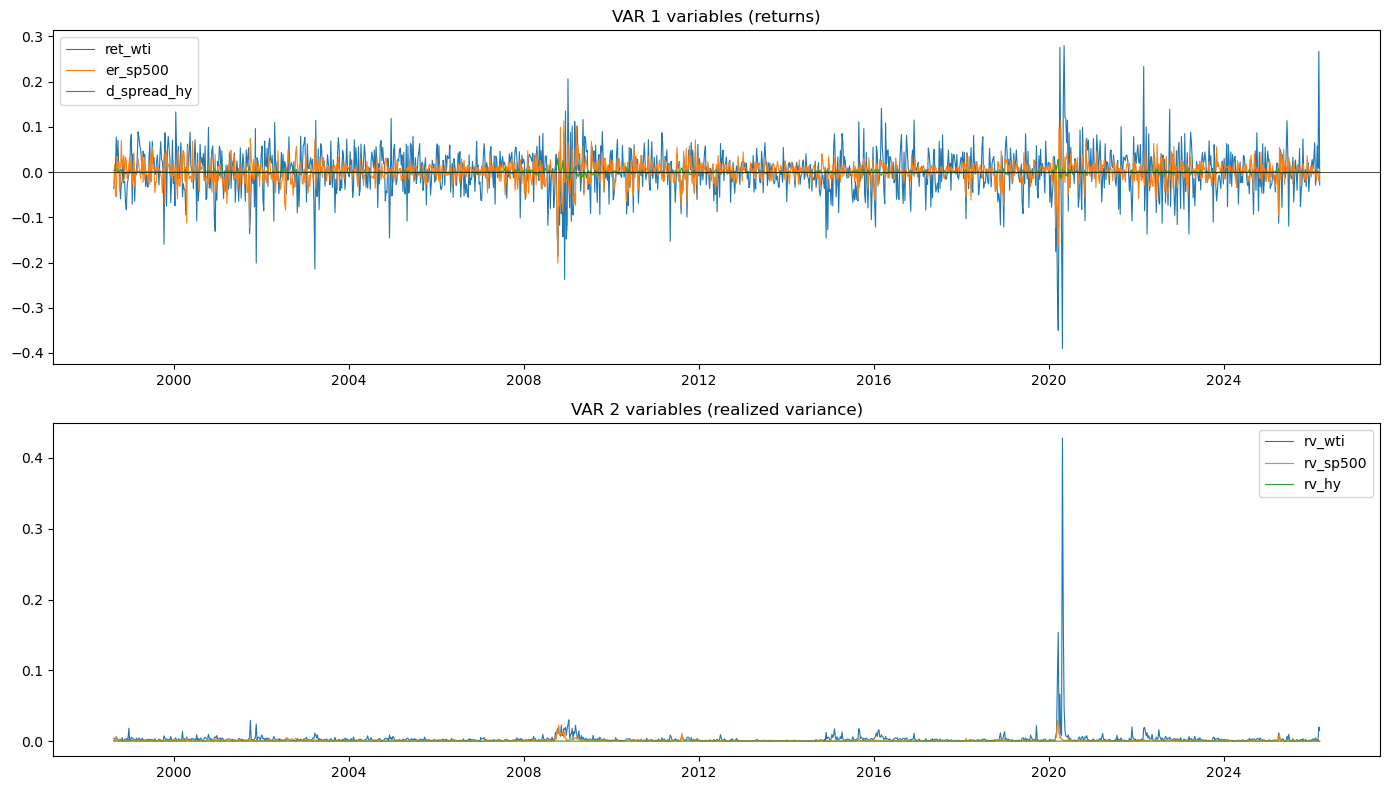

In [21]:
import matplotlib.pyplot as plt

# quick check on the final dataset
print(df_final.describe().round(6).to_string())

# plot to visually confirm the series look reasonable
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for col in ["ret_wti", "er_sp500", "d_spread_hy"]:
    axes[0].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("VAR 1 variables (returns)")
axes[0].legend()

for col in ["rv_wti", "rv_sp500", "rv_hy"]:
    axes[1].plot(df_final.index, df_final[col], label=col, linewidth=0.8)
axes[1].set_title("VAR 2 variables (realized variance)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [22]:
df_final.to_csv(Path("../data/processed/weekly_cleaned_data.csv"))
print("Exported: ../data/processed/weekly_cleaned_data.csv")

Exported: ../data/processed/weekly_cleaned_data.csv
